## Problem 9.2 - Classification with SVM

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import LinearSegmentedColormap

In [16]:
# truncate the colormap RdPu (I just do that for aesthetic reasons)
truncated_RdPu = LinearSegmentedColormap.from_list('truncated_RdPu', plt.cm.RdPu(np.linspace(0.3, 0.8, 100))) 

In [17]:
# create data set of cencentric circles
X, y = make_circles(n_samples = 500, factor = 0.7, noise = 0.12, random_state = 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

### (i) SVM with linear kernel

In [18]:
# fit the model with a linear kernel
class_linear = SVC(kernel = 'linear')
class_linear.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


[]

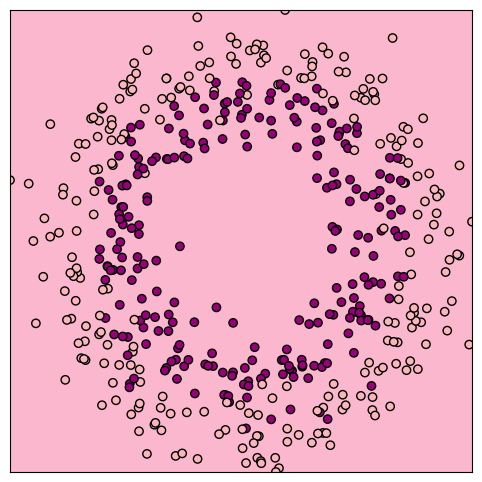

In [19]:
# plot the Decision boundary
fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot()
x0, x1 = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 500).reshape(-1, 1),
    np.linspace(X[:,1].min(), X[:,1].max(), 500).reshape(-1, 1)
)
x_new = np.c_[x0.ravel(), x1.ravel()]
y_pred = class_linear.predict(x_new)
zz = y_pred.reshape(x0.shape)

plt.contourf(x0, x1, zz, alpha = 0.6, cmap = truncated_RdPu)
plt.contour(x0, x1, zz, colors = ['black'], linewidths = [0.4])
plt.scatter(X[:,0], X[:,1], c = y, edgecolors = 'k', cmap = truncated_RdPu)
ax.set_box_aspect(1)
ax.xaxis.set_tick_params(labelbottom = False)
ax.yaxis.set_tick_params(labelleft = False)
ax.set_xticks([])
ax.set_yticks([])

In [20]:
svm_train_accuracy = np.mean(class_linear.predict(X_train) == y_train)
print(f'SVM Training Accuracy: {svm_train_accuracy:.2f}')
svm_test_accuracy = np.mean(class_linear.predict(X_test) == y_test)
print(f'SVM Test Accuracy: {svm_test_accuracy:.2f}')

SVM Training Accuracy: 0.52
SVM Test Accuracy: 0.43


**Observations:**

- The model cannot separate our data, since the concentric circles are not linearly separable in 2D. 
- The Training and Test accuracy are unusually low.
- The decision boundary is outside of the picture we plotted, which is reasonable since we have only a 50% chance of predicting data correctly.

### (ii) Considering different kernels

In [26]:
kernels = ['rbf', 'poly', 'sigmoid']

SVM Training Accuracy(rbf): 0.90
SVM Test Accuracy(rbf): 0.90
SVM Training Accuracy(poly): 0.52
SVM Test Accuracy(poly): 0.43
SVM Training Accuracy(sigmoid): 0.50
SVM Test Accuracy(sigmoid): 0.48


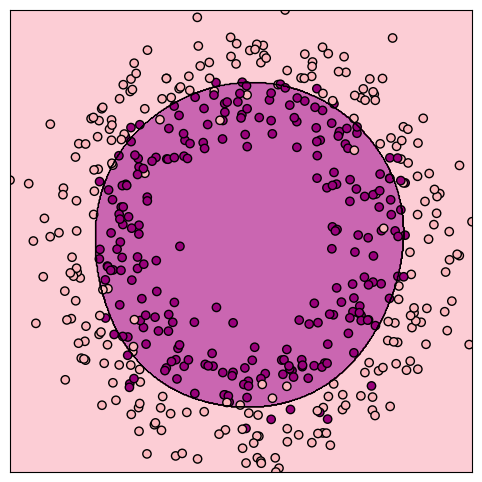

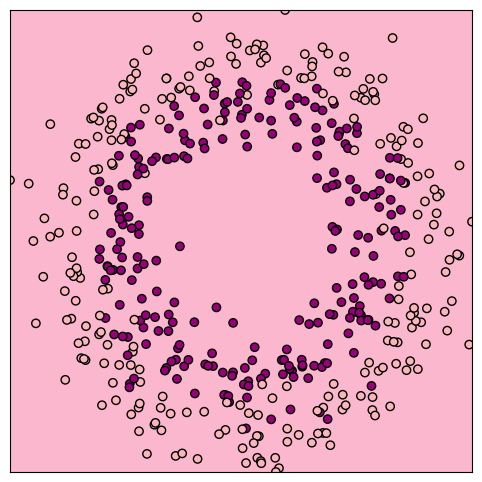

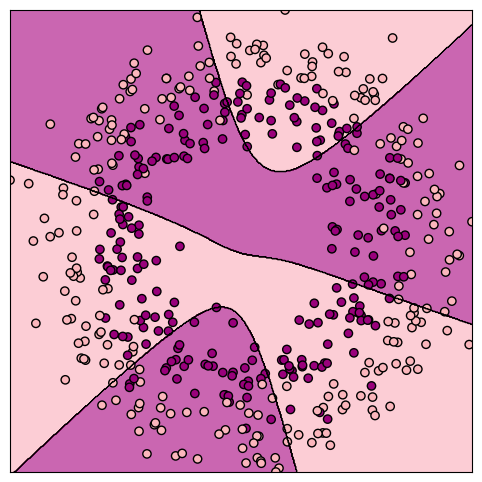

In [27]:
for kernel in kernels:
    class_kernel = SVC(kernel = kernel, degree = 3)
    class_kernel.fit(X_train, y_train) 

    fig = plt.figure(figsize = (8, 6))
    ax = fig.add_subplot()
    x0, x1 = np.meshgrid(
        np.linspace(X[:,0].min(), X[:,0].max(), 500).reshape(-1, 1),
        np.linspace(X[:,1].min(), X[:,1].max(), 500).reshape(-1, 1)
    )
    x_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = class_kernel.predict(x_new)
    zz = y_pred.reshape(x0.shape)

    plt.contourf(x0, x1, zz, alpha = 0.6, cmap = truncated_RdPu)
    plt.contour(x0, x1, zz, colors = ['black'], linewidths = [0.4])
    plt.scatter(X[:,0], X[:,1], c = y, edgecolors = 'k', cmap = truncated_RdPu)
    ax.set_box_aspect(1)
    ax.xaxis.set_tick_params(labelbottom = False)
    ax.yaxis.set_tick_params(labelleft = False)
    ax.set_xticks([])
    ax.set_yticks([])

    svm_train_accuracy_kernel = np.mean(class_kernel.predict(X_train) == y_train)
    print(f'SVM Training Accuracy({kernel}): {svm_train_accuracy_kernel:.2f}')
    svm_test_accuracy_kernel = np.mean(class_kernel.predict(X_test) == y_test)
    print(f'SVM Test Accuracy({kernel}): {svm_test_accuracy_kernel:.2f}')

**Observations:**

- With the rbf kernel we can seperate the data better.
- The Training and Test Accuracy is much higher.
- The other kernels (poly and sigmoid) are still around as bad as the linear kernel.

When using the rbf Kernel, the inner ring maps to small radius values while the outer ring maps to large radius values. The circles then becomes linearly separable.  
When projecting back to the 2D space we get a circular decision boundary. 